In [ ]:
 # !pip install darts --quiet

In [ ]:
# !pip install numpy==1.26.4 pmdarima==2.0.4 --force-reinstall
# import os
# os.kill(os.getpid(), 9)

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import torch.nn as nn
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from tensorflow.keras.utils import plot_model

# Read Data & Feature Technical


In [ ]:
df = pd.read_csv('GABUNGAN_DATA_SAHAM_DAN_SENTIMEN.csv', parse_dates=['tanggal'])
df = df.sort_values('tanggal')

In [ ]:
# Fitur teknikal dasar
df['return'] = df['Terakhir'].pct_change() # <- buat melihat return harian (persentase perubahan)
df['lag1_return'] = df['return'].shift(1) # <- untuk melihat pengaruh return sebelumnya terhadap return saat ini
df['ma5'] = df['Terakhir'].rolling(5).mean().shift(1) # <- membuat moving average 5 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['ma10'] = df['Terakhir'].rolling(10).mean().shift(1) # <- membuat moving average 10 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['volatility5'] = df['return'].rolling(5).std().shift(1) # <- menghitung volatility 5 hari terakhir dan digeser 1 hari ke belakang
df['dayofweek'] = df['tanggal'].dt.dayofweek # <- mengambil hari dalam minggu

In [ ]:
df.head()

,tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,avg_sentiment,prop_pos,prop_neg,max_impact,avg_sentiment_result,return,lag1_return,ma5,ma10,volatility5,dayofweek
0,2022-01-03,666531,658626,667720,658613,1.826000e+10,1.27,0.834439,0.160000,0.360000,netral,positif,NaN,NaN,NaN,NaN,NaN,0
1,2022-01-04,669537,667513,672066,667513,1.859000e+10,0.45,0.814955,0.440000,0.360000,positif,positif,0.004510,NaN,NaN,NaN,NaN,1
2,2022-01-05,666230,670317,673811,663484,1.791000e+10,-0.49,0.959284,0.230769,0.615385,negatif,positif,-0.004939,0.004510,NaN,NaN,NaN,2
3,2022-01-06,665335,667485,667985,659323,1.800000e+10,-0.13,0.912079,0.266667,0.400000,negatif,positif,-0.001343,-0.004939,NaN,NaN,NaN,3
4,2022-01-07,670132,666951,671215,664771,1.571000e+10,0.72,0.777768,0.083333,0.666667,negatif,positif,0.007210,-0.001343,NaN,NaN,NaN,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal               724 non-null    datetime64[ns]
 1   Terakhir              724 non-null    int64         
 2   Pembukaan             724 non-null    int64         
 3   Tertinggi             724 non-null    int64         
 4   Terendah              724 non-null    int64         
 5   Vol.                  722 non-null    float64       
 6   Perubahan%            724 non-null    float64       
 7   avg_sentiment         724 non-null    float64       
 8   prop_pos              724 non-null    float64       
 9   prop_neg              724 non-null    float64       
 10  max_impact            724 non-null    object        
 11  avg_sentiment_result  724 non-null    object        
 12  return                723 non-null    float64       
 13  lag1_return         

In [ ]:
df.dropna(axis=0, inplace=True) #menghapus nilai N/A

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 10 to 723
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal               712 non-null    datetime64[ns]
 1   Terakhir              712 non-null    int64         
 2   Pembukaan             712 non-null    int64         
 3   Tertinggi             712 non-null    int64         
 4   Terendah              712 non-null    int64         
 5   Vol.                  712 non-null    float64       
 6   Perubahan%            712 non-null    float64       
 7   avg_sentiment         712 non-null    float64       
 8   prop_pos              712 non-null    float64       
 9   prop_neg              712 non-null    float64       
 10  max_impact            712 non-null    object        
 11  avg_sentiment_result  712 non-null    object        
 12  return                712 non-null    float64       
 13  lag1_return           71

In [ ]:
impact_mapping = {'negatif': -1, 'netral': 0, 'positif': 1}
df['max_impact'] = df['max_impact'].map(impact_mapping)
df['avg_sentiment_result'] = df['avg_sentiment_result'].map(impact_mapping)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df[['Pembukaan', 'Tertinggi', 'Terendah', 'Vol.', 'Perubahan%',
        'avg_sentiment', 'prop_pos', 'prop_neg', 'max_impact', 'avg_sentiment_result',
        'return', 'lag1_return', 'ma5', 'ma10', 'volatility5', 'dayofweek']]
y = df['Terakhir'].shift(-1)

mask = ~(X.isna().any(axis=1) | y.isna())
X_clean = X[mask]
y_clean = y[mask]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_clean, y_clean)

importance = pd.Series(model.feature_importances_, index=X_clean.columns)
print(importance.sort_values(ascending=False))

Terendah                0.526098
Tertinggi               0.325100
Pembukaan               0.116264
return                  0.003524
lag1_return             0.003485
Perubahan%              0.003408
ma10                    0.003323
volatility5             0.003264
avg_sentiment           0.003011
Vol.                    0.002903
ma5                     0.002898
prop_pos                0.002596
prop_neg                0.002462
dayofweek               0.001278
max_impact              0.000388
avg_sentiment_result    0.000000
dtype: float64


# Spliting data menggunakan chronological

In [ ]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Pembukaan',
                'Tertinggi',
                'Terendah',
                'Vol.',
                'avg_sentiment',
                'prop_pos',
                'prop_neg',
                'return',
                'lag1_return',
                'ma5',
                'ma10',
                'volatility5']

df['target'] = df['Terakhir'].shift(-1)

train = df[(df['tanggal'] >= "2022-01-03") & (df['tanggal'] <= "2022-12-31")].copy()
val   = df[(df['tanggal'] >= "2023-01-03") & (df['tanggal'] <= "2023-06-30")].copy()
test  = df[(df['tanggal'] >= "2023-07-01") & (df['tanggal'] <= "2024-12-31")].copy()

# Drop NA akibat rolling & shift
train = train[feature_cols + ['target']].dropna()
val   = val[feature_cols + ['target']].dropna()
test  = test[feature_cols + ['target']].dropna()

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train[feature_cols])
scaler_y.fit(train[['target']])

def scale(df):
    X = pd.DataFrame(
        scaler_X.transform(df[feature_cols]),
        columns=feature_cols,
        index=df.index
    )
    y = pd.DataFrame(
        scaler_y.transform(df[['target']]),
        columns=['target_scaled'],
        index=df.index
    )
    return pd.concat([X, y], axis=1)

train_scaled = scale(train)
val_scaled   = scale(val)
test_scaled  = scale(test)


In [ ]:
import numpy as np

def create_sequences(df_scaled, seq_len):
    X, y = [], []
    for i in range(seq_len, len(df_scaled)):
        X.append(
            df_scaled.iloc[i-seq_len:i]
            .drop(columns=['target_scaled'])
            .values
        )
        y.append(df_scaled['target_scaled'].iloc[i])
    return np.array(X), np.array(y)

SEQ_LEN = 1

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val,   y_val   = create_sequences(val_scaled,   SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)


# LSTM

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import models, layers, callbacks

model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train.shape[2])),
    layers.Masking(), #buat ngatasin overfitting
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=32,
    callbacks=[es], verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 412ms/step - loss: 0.9325 - mae: 0.8025 - val_loss: 1.4884 - val_mae: 1.0992
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.8486 - mae: 0.7667 - val_loss: 1.3616 - val_mae: 1.0448
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.7798 - mae: 0.7330 - val_loss: 1.1674 - val_mae: 0.9560
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6814 - mae: 0.6864 - val_loss: 0.8921 - val_mae: 0.8168
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5470 - mae: 0.6006 - val_loss: 0.5640 - val_mae: 0.6239
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.4251 - mae: 0.5320 - val_loss: 0.2683 - val_mae: 0.3971
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2632 - mae: 0.4073 - val_loss: 0.1697 - val_mae: 0.2921
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2391 - mae: 0.3700 - val_loss: 0.1628 - val_mae: 0.2870
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2128 - mae

In [ ]:
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 1, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,653 (389.27 KB)

 Trainable params: 33,217 (129.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 66,436 (259.52 KB)

In [ ]:
y_pred_scaled_lstm = model_lstm.predict(X_test)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled_lstm)
y_true_lstm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
lstm_mae = mean_absolute_error(y_true_lstm, y_pred_lstm)
lstm_mse = mean_squared_error(y_true_lstm, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mape = np.mean(np.abs((y_true_lstm - y_pred_lstm) / y_true_lstm)) * 100

print(f"MAE  : {lstm_mae}")
print(f"MSE  : {lstm_mse}")
print(f"RMSE : {lstm_rmse}")
print(f"MAPE : {lstm_mape:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
MAE  : 12797.483680555555
MSE  : 307112281.84798175
RMSE : 17524.619306791854
MAPE : 1.73%


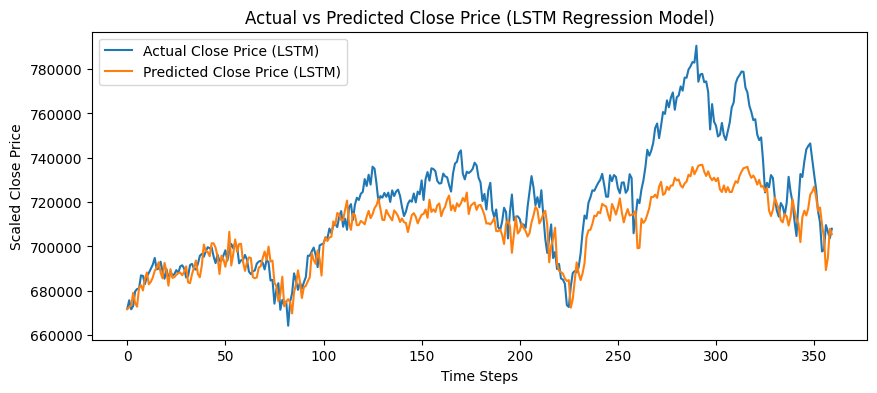

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_true_lstm.flatten(), label="Actual Close Price (LSTM)")
plt.plot(y_pred_lstm.flatten(), label="Predicted Close Price (LSTM)")
plt.title("Actual vs Predicted Close Price (LSTM Regression Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual_Change': y_true_lstm.flatten(),
    'LSTM_Predicted_Change': y_pred_lstm.flatten()
})

print("Comparison of Actual vs. Predicted Stock Price Change:")
display(comparison_df.head())

Comparison of Actual vs. Predicted Stock Price Change:


,Actual_Change,LSTM_Predicted_Change
0,671898.0,671706.8750
1,675733.0,672619.0625
2,671646.0,673362.9375
3,673104.0,679069.6250
4,679692.0,674506.3750


# SARIMAX

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:               SARIMAX(2, 0, 1)   Log Likelihood                 -71.277
Date:                Mon, 26 Jan 2026   AIC                            174.553
Time:                        04:51:21   BIC                            229.838
Sample:                             0   HQIC                           196.844
                                - 236                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Pembukaan         0.7677      0.227      3.380      0.001       0.322       1.213
Tertinggi         0.0606      0.152      0.399      0.690      -0.237       0.358
Terendah         -0.0658      0.163     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

  Progress: 20/113


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

...

  Progress: 300/361


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

  Progress: 350/361


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq

Testing complete: 361 predictions

EVALUATION METRICS

Validation Set:
  RMSE: 4495.56
  MAE:  3404.57
  MAPE: 0.50%

Test Set:
  RMSE: 5723.25
  MAE:  4453.94
  MAPE: 0.62%


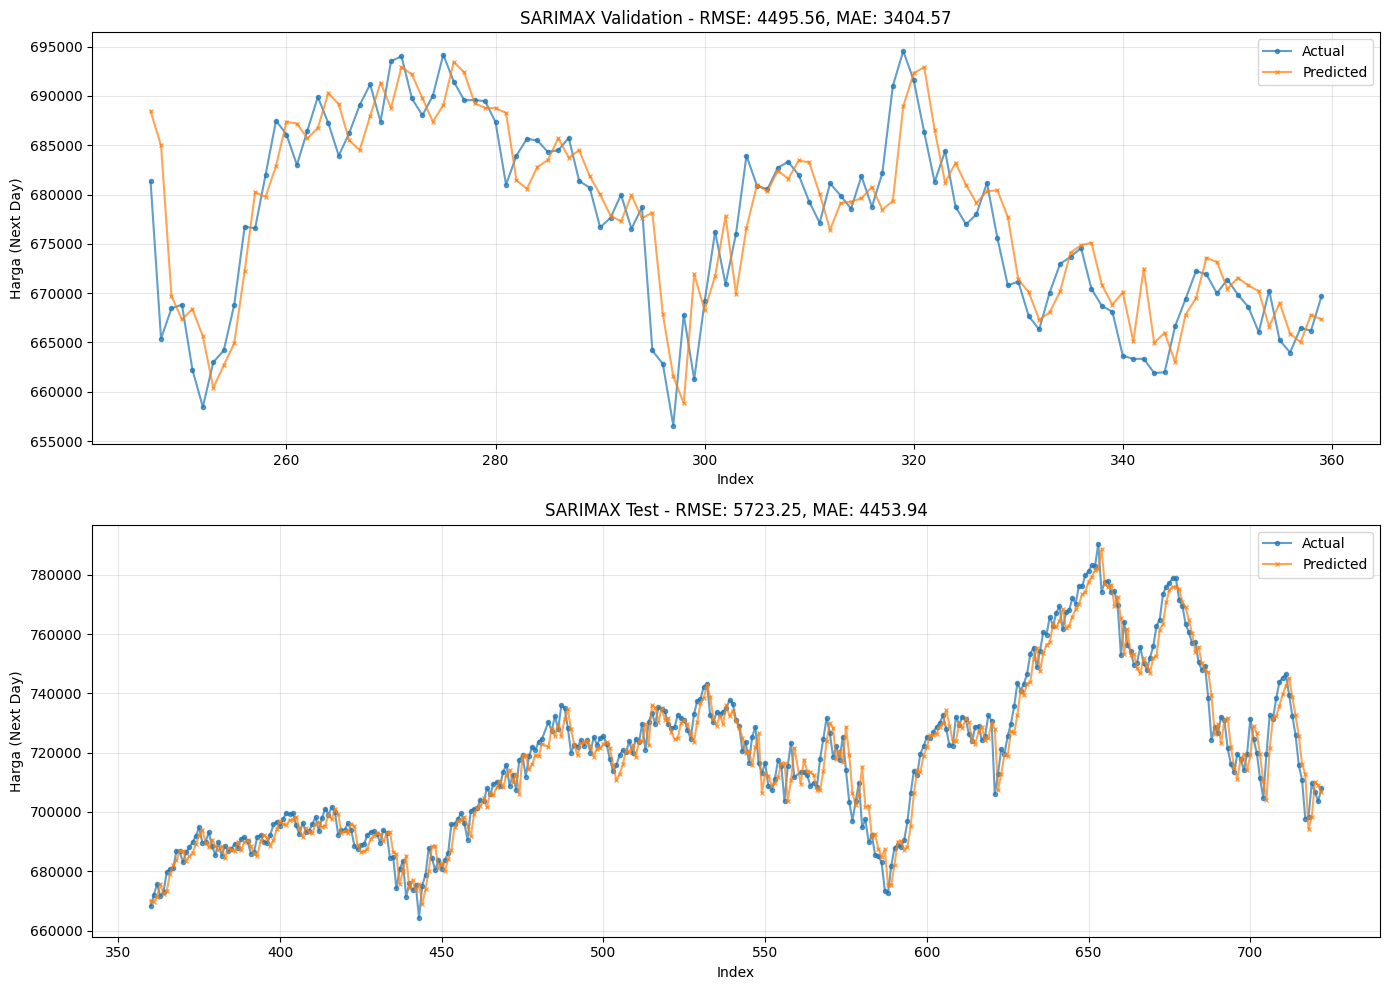

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

features = feature_cols

y_train_sarimax = train_scaled['target_scaled']
X_train_sarimax = train_scaled[features]

y_val_sarimax = val_scaled['target_scaled']
X_val_sarimax = val_scaled[features]

y_test_sarimax = test_scaled['target_scaled']
X_test_sarimax = test_scaled[features]

model = SARIMAX(
    endog=y_train_sarimax,
    exog=X_train_sarimax,
    order=(2, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())
print("\n" + "="*60)

print("VALIDATING...")
predictions_val_scaled = []
last_valid_pred_val = y_train_sarimax.iloc[-1] if not y_train_sarimax.empty and np.isfinite(y_train_sarimax.iloc[-1]) else 0.0

for i in range(len(y_val_sarimax)):

    current_idx = y_val_sarimax.index[i]

    try:
        if i == 0:
            pred_scaled = results.forecast(steps=1, exog=X_val_sarimax.iloc[[i]])
        else:
            updated_endog = pd.concat([y_train_sarimax, y_val_sarimax.iloc[:i]])
            updated_exog = pd.concat([X_train_sarimax, X_val_sarimax.iloc[:i]])

            model_updated = SARIMAX(
                endog=updated_endog,
                exog=updated_exog,
                order=(2, 0, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            try:
                results_updated = model_updated.fit(start_params=results.params, disp=False)
            except Exception as fit_e:
                print(f"  Warning: Model fit failed at validation step {i} (updating model). Error: {fit_e}")
                results_updated = results

            pred_scaled = results_updated.forecast(steps=1, exog=X_val_sarimax.iloc[[i]])

        forecast_value = pred_scaled.values[0]
        if not np.isfinite(forecast_value):
            predictions_val_scaled.append(last_valid_pred_val)
        else:
            predictions_val_scaled.append(forecast_value)
            last_valid_pred_val = forecast_value
    except Exception as e:
        print(f"Warning: Prediction failed at validation step {i}. Using last valid prediction. Error: {e}")
        predictions_val_scaled.append(last_valid_pred_val)

    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(y_val_sarimax)}")

print(f"Validation complete: {len(predictions_val_scaled)} predictions")

print("\n" + "="*60)
print("TESTING...")
predictions_test_scaled = []

y_train_val = pd.concat([y_train_sarimax, y_val_sarimax])
X_train_val = pd.concat([X_train_sarimax, X_val_sarimax])

model_full = SARIMAX(
    endog=y_train_val,
    exog=X_train_val,
    order=(2, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_full = model_full.fit(disp=False)

last_valid_pred_test = y_train_val.iloc[-1] if not y_train_val.empty and np.isfinite(y_train_val.iloc[-1]) else 0.0

for i in range(len(y_test_sarimax)):
    try:
        if i == 0:
            pred_scaled = results_full.forecast(steps=1, exog=X_test_sarimax.iloc[[i]])
        else:
            updated_endog = pd.concat([y_train_val, y_test_sarimax.iloc[:i]])
            updated_exog = pd.concat([X_train_val, X_test_sarimax.iloc[:i]])

            model_updated = SARIMAX(
                endog=updated_endog,
                exog=updated_exog,
                order=(2, 0, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            try:
                results_updated = model_updated.fit(start_params=results_full.params, disp=False)
            except Exception as fit_e:
                print(f"  Warning: Model fit failed at testing step {i} (updating model). Error: {fit_e}")
                results_updated = results_full

            pred_scaled = results_updated.forecast(steps=1, exog=X_test_sarimax.iloc[[i]])
        forecast_value = pred_scaled.values[0]
        if not np.isfinite(forecast_value):
            predictions_test_scaled.append(last_valid_pred_test)
        else:
            predictions_test_scaled.append(forecast_value)
            last_valid_pred_test = forecast_value
    except Exception as e:
        print(f"Warning: Prediction failed at testing step {i}. Using last valid prediction. Error: {e}")
        predictions_test_scaled.append(last_valid_pred_test)

    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(y_test_sarimax)}")

print(f"Testing complete: {len(predictions_test_scaled)} predictions")

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

if not all(np.isfinite(x) for x in predictions_val_scaled):
    print("Debug: predictions_val_scaled still contains non-finite values. Replacing with last valid.")
    for j in range(len(predictions_val_scaled)):
        if not np.isfinite(predictions_val_scaled[j]):
            predictions_val_scaled[j] = last_valid_pred_val

pred_val_ori = scaler_y.inverse_transform(np.array(predictions_val_scaled).reshape(-1, 1))
y_val_ori = scaler_y.inverse_transform(y_val_sarimax.values.reshape(-1, 1))

val_rmse = np.sqrt(mean_squared_error(y_val_ori, pred_val_ori))
val_mae = mean_absolute_error(y_val_ori, pred_val_ori)
val_mape = np.mean(np.abs((y_val_ori - pred_val_ori) / y_val_ori)) * 100

if not all(np.isfinite(x) for x in predictions_test_scaled):
    print("Debug: predictions_test_scaled still contains non-finite values. Replacing with last valid.")
    for j in range(len(predictions_test_scaled)):
        if not np.isfinite(predictions_test_scaled[j]):
            predictions_test_scaled[j] = last_valid_pred_test

pred_test_ori = scaler_y.inverse_transform(np.array(predictions_test_scaled).reshape(-1, 1))
y_test_ori = scaler_y.inverse_transform(y_test_sarimax.values.reshape(-1, 1))

sarimax_rmse = np.sqrt(mean_squared_error(y_test_ori, pred_test_ori))
sarimax_mae = mean_absolute_error(y_test_ori, pred_test_ori)
sarimax_mape = np.mean(np.abs((y_test_ori - pred_test_ori) / y_test_ori)) * 100
sarimax_mse = mean_squared_error(y_test_ori, pred_test_ori) # Add MSE

print(f"\nValidation Set:")
print(f"  RMSE: {val_rmse:.2f}")
print(f"  MAE:  {val_mae:.2f}")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTest Set:")
print(f"  RMSE: {sarimax_rmse:.2f}")
print(f"  MAE:  {sarimax_mae:.2f}")
print(f"  MAPE: {sarimax_mape:.2f}%")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(val_scaled.index, y_val_ori, label='Actual', marker='o', markersize=3, alpha=0.7)
axes[0].plot(val_scaled.index, pred_val_ori, label='Predicted', marker='x', markersize=3, alpha=0.7)
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Harga (Next Day)')
axes[0].set_title(f'SARIMAX Validation - RMSE: {val_rmse:.2f}, MAE: {val_mae:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_scaled.index, y_test_ori, label='Actual', marker='o', markersize=3, alpha=0.7)
axes[1].plot(test_scaled.index, pred_test_ori, label='Predicted', marker='x', markersize=3, alpha=0.7)
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Harga (Next Day)')
axes[1].set_title(f'SARIMAX Test - RMSE: {sarimax_rmse:.2f}, MAE: {sarimax_mae:.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sarimax_mse = mean_squared_error(y_test_ori, pred_test_ori)
sarimax_mae = mean_absolute_error(y_test_ori, pred_test_ori)
sarimax_rmse = np.sqrt(sarimax_mse)
sarimax_mape = np.mean(np.abs((y_test_ori - pred_test_ori) / y_test_ori))

print(f"MSE: {sarimax_mse}")
print(f"MAE: {sarimax_mae}")
print(f"RMSE: {sarimax_rmse}")
print(f"MAPE: {sarimax_mape}")

MSE: 32755575.12683007
MAE: 4453.9361394759235
RMSE: 5723.24865149419
MAPE: 0.006196361095192512


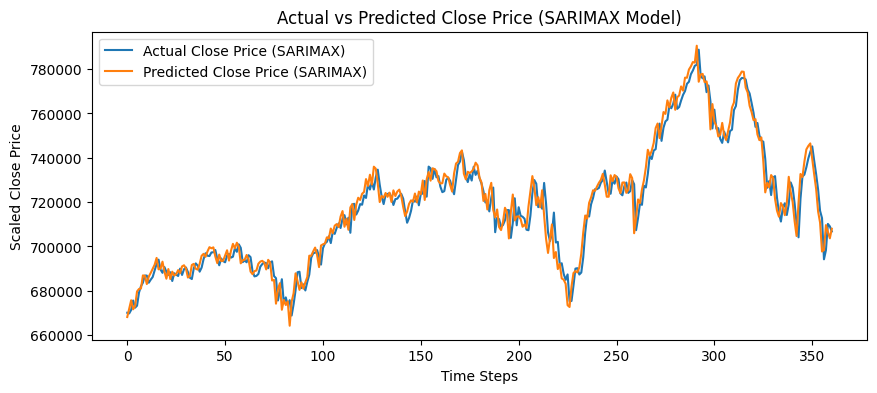

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(pred_test_ori.flatten(), label="Actual Close Price (SARIMAX)")
plt.plot(y_test_ori.flatten(), label="Predicted Close Price (SARIMAX)")
plt.title("Actual vs Predicted Close Price (SARIMAX Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual_Change':  y_test_ori.flatten(),
    'SARIMAX_Predicted_Change': pred_test_ori.flatten()
})

print("Comparison of Actual vs. Predicted Stock Price Change:")
display(comparison_df.head())

Comparison of Actual vs. Predicted Stock Price Change:


,Actual_Change,SARIMAX_Predicted_Change
0,668175.0,670089.695317
1,671898.0,669789.276599
2,675733.0,671374.927164
3,671646.0,675629.762997
4,673104.0,672374.073560


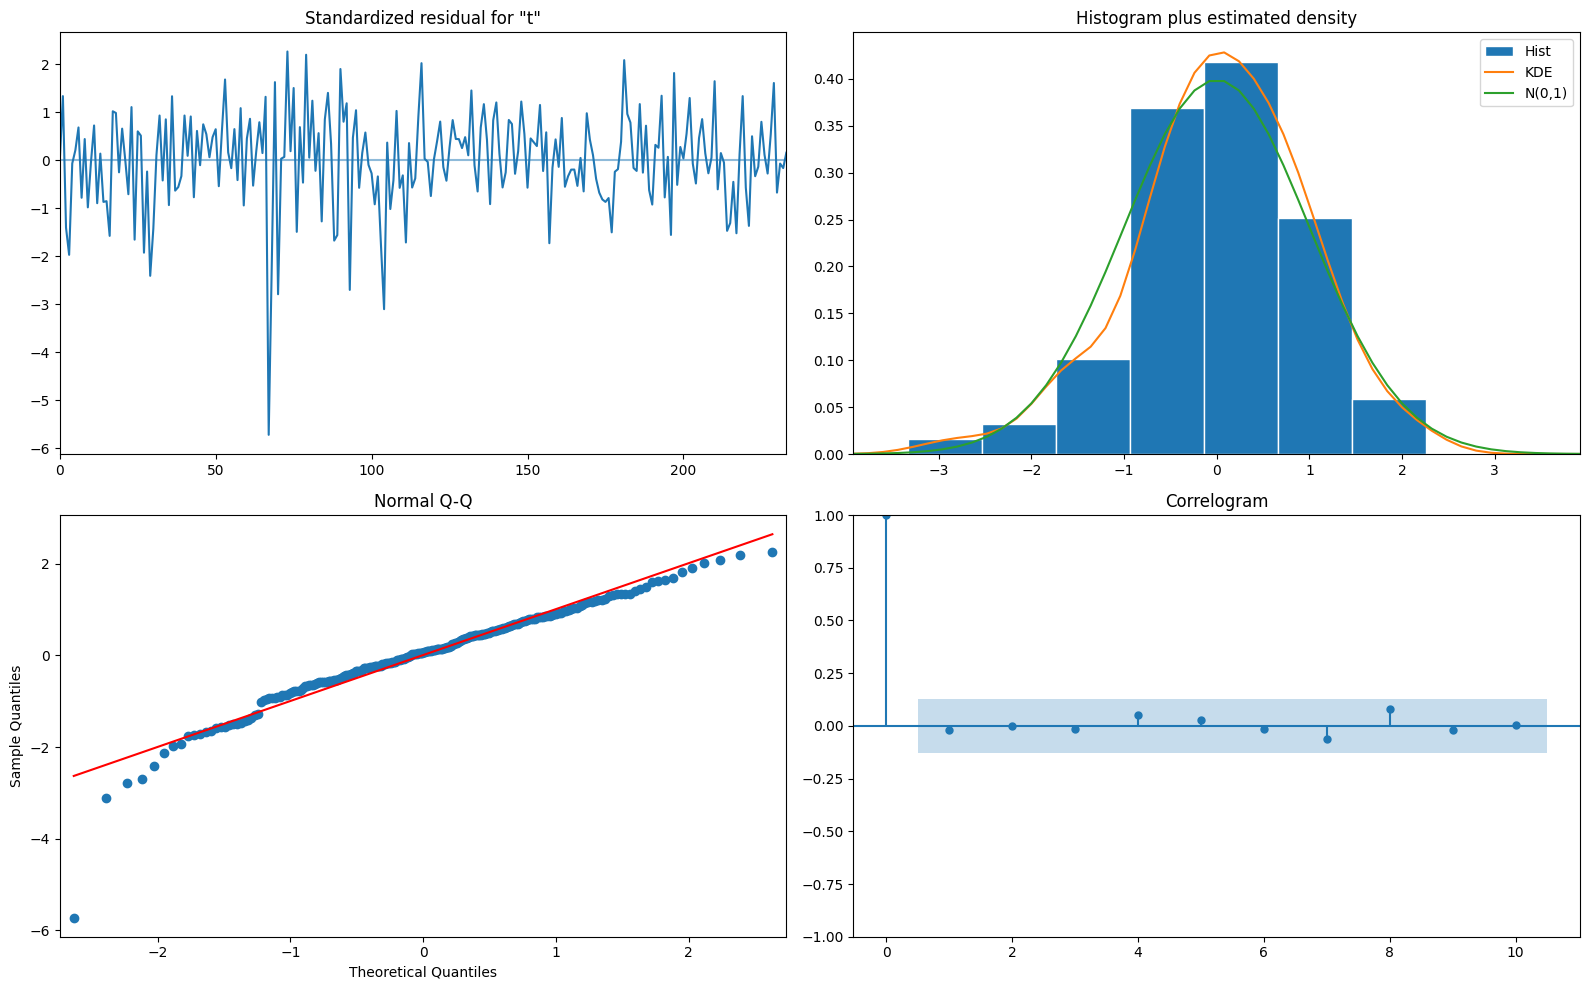

In [ ]:
results.plot_diagnostics(figsize=(16, 10))
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(results_full.resid.dropna(), lags=[10, 20, 30], return_df=True)
print(lb_test)


      lb_stat  lb_pvalue
10   4.794007   0.904507
20  13.708492   0.844963
30  28.536117   0.542049


# N-Beats

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

def nbeats_block(x, units, input_dim, name_prefix=''):
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc1')(x)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc2')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc3')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc4')(h)
    backcast = layers.Dense(input_dim, name=f'{name_prefix}_backcast')(h)
    forecast = layers.Dense(1, name=f'{name_prefix}_forecast')(h)

    return backcast, forecast

input_dim = SEQ_LEN * len(feature_cols)
inputs = layers.Input(shape=(input_dim,), name='input')

backcast1, forecast1 = nbeats_block(inputs, units=128, input_dim=input_dim, name_prefix='generic1')
res1 = layers.Subtract(name='residual1')([inputs, backcast1])

backcast2, forecast2 = nbeats_block(res1, units=128, input_dim=input_dim, name_prefix='generic2')
res2 = layers.Subtract(name='residual2')([res1, backcast2])

backcast3, forecast3 = nbeats_block(res2, units=64, input_dim=input_dim, name_prefix='trend1')
res3 = layers.Subtract(name='residual3')([res2, backcast3])

backcast4, forecast4 = nbeats_block(res3, units=64, input_dim=input_dim, name_prefix='trend2')

output = layers.Add(name='final_forecast')([forecast1, forecast2, forecast3, forecast4])

model_nbeats = Model(inputs=inputs, outputs=output, name='NBEATS')
model_nbeats.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model_nbeats.summary())

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nData shapes:")
print(f"X_train_flat: {X_train_flat.shape}")
print(f"y_train: {y_train.shape}")

es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model_nbeats.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es, reduce_lr],
    verbose=1
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled_nbeats = model_nbeats.predict(X_test_flat)
y_pred_nbeats = scaler_y.inverse_transform(y_pred_scaled_nbeats)
y_true_nbeats = scaler_y.inverse_transform(y_test.reshape(-1, 1))

mae_nbeats = mean_absolute_error(y_true_nbeats, y_pred_nbeats)
mse_nbeats = mean_squared_error(y_true_nbeats, y_pred_nbeats)
rmse_nbeats = np.sqrt(mse_nbeats)
mape_nbeats = np.mean(np.abs((y_true_nbeats - y_pred_nbeats) / y_true_nbeats)) * 100

print("\n" + "="*60)
print("N-BEATS MODEL PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_nbeats:.2f}")
print(f"RMSE : {rmse_nbeats:.2f}")
print(f"MAPE : {mape_nbeats:.2f}%")
print(f"MSE  : {mse_nbeats:.2f}")

Model: "NBEATS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 12)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc1        │ (None, 128)       │      1,664 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc2        │ (None, 128)       │     16,512 │ generic1_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc3        │ (None, 128)       │     16,512 │ generic1_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc4        │ (None, 128)       │     16,512 │ generic1_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_backcast   │ (None, 12)        │      1,548 │ generic1_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual1           │ (None, 12)        │          0 │ input[0][0],      │
│ (Subtract)          │                   │            │ generic1_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc1        │ (None, 128)       │      1,664 │ residual1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc2        │ (None, 128)       │     16,512 │ generic2_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc3        │ (None, 128)       │     16,512 │ generic2_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc4        │ (None, 128)       │     16,512 │ generic2_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_backcast   │ (None, 12)        │      1,548 │ generic2_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual2           │ (None, 12)        │          0 │ residual1[0][0],  │
│ (Subtract)          │                   │            │ generic2_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc1 (Dense)  │ (None, 64)        │        832 │ residual2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc2 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc3 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc4 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_backcast     │ (None, 12)        │        780 │ trend1_fc4[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 133,288 (520.66 KB)

 Trainable params: 133,288 (520.66 KB)

 Non-trainable params: 0 (0.00 B)

None

Data shapes:
X_train_flat: (235, 12)
y_train: (235,)
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.6346 - mae: 0.6281 - val_loss: 0.2396 - val_mae: 0.3877 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2181 - mae: 0.3588 - val_loss: 0.5540 - val_mae: 0.6557 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1919 - mae: 0.3362 - val_loss: 0.1326 - val_mae: 0.2688 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1409 - mae: 0.2915 - val_loss: 0.1643 - val_mae: 0.3206 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1267 - mae: 0.2605 - val_loss: 0.1507 - val_mae: 0.3030 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0878 - mae: 0.2219 - val_loss: 0.1316 - val_mae: 0.2804 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0813 - mae: 0.2074 - val_loss: 0.1566 - v

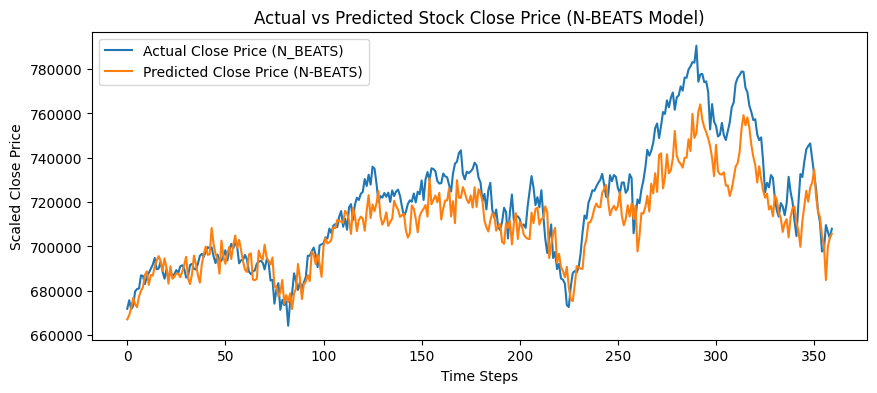

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_true_nbeats.flatten(), label="Actual Close Price (N_BEATS)")
plt.plot(y_pred_nbeats.flatten(), label="Predicted Close Price (N-BEATS)")
plt.title("Actual vs Predicted Stock Close Price (N-BEATS Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual_Change':  y_true_nbeats.flatten(),
    'SARIMAX_Predicted_Change': y_pred_nbeats.flatten()
})

print("Comparison of Actual vs. Predicted Stock Price Change:")
display(comparison_df.head())

Comparison of Actual vs. Predicted Stock Price Change:


,Actual_Change,SARIMAX_Predicted_Change
0,671898.0,667115.3125
1,675733.0,669011.0625
2,671646.0,672152.3125
3,673104.0,676816.1875
4,679692.0,673987.7500


# ARIMA BASELINE WITHOUT SENTIMEN ANALYSIS

ARIMA(1,0,0) - SAME ORDER AS SARIMAX

Training ARIMA(2, 1, 2)...
                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 -65.785
Date:                Mon, 26 Jan 2026   AIC                            141.570
Time:                        05:09:39   BIC                            158.868
Sample:                             0   HQIC                           148.544
                                - 236                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7712      0.150      5.134      0.000       0.477       1.066
ar.L2         -0.6748      0.148     -4.551      0.000      -0.965

<Figure size 640x480 with 0 Axes>

Generating diagnostic plots...


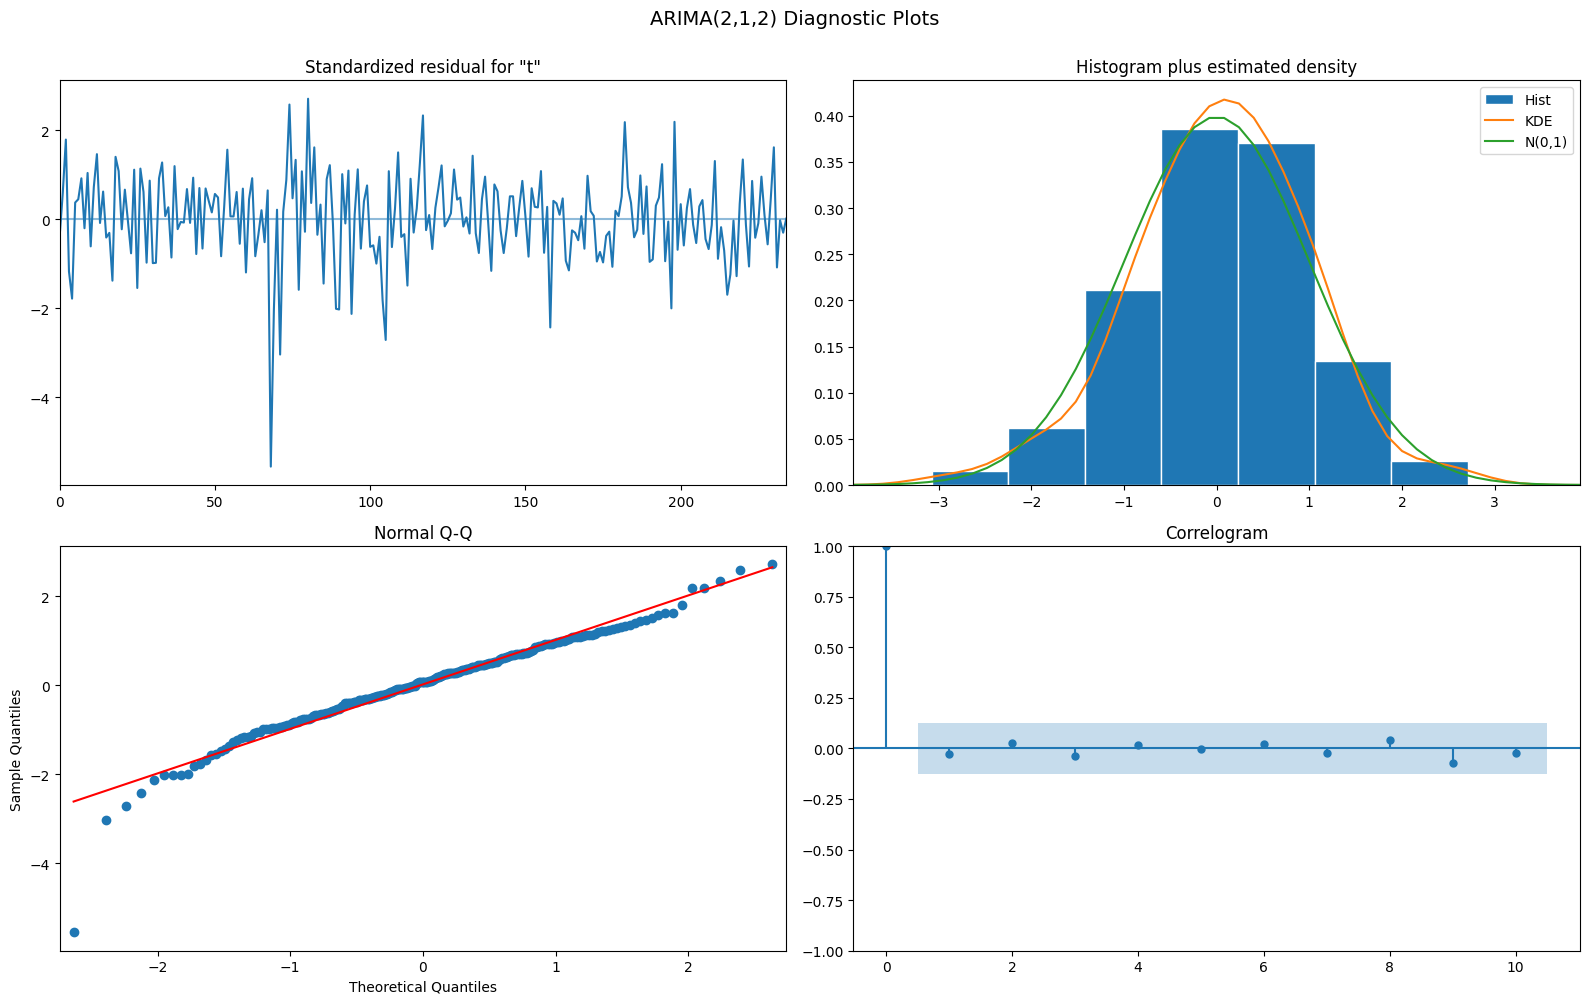


RESULTS SUMMARY
Model: ARIMA(2,1,2)
MAE: 4214.01
RMSE: 5524.35
MAPE: 0.59


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("ARIMA(1,0,0) - SAME ORDER AS SARIMAX")
print("="*60)

best_order = (2, 1, 2)

print(f"\nTraining ARIMA{best_order}...")

model_arima = ARIMA(y_train_sarimax, order=best_order)
results_arima = model_arima.fit()

print(results_arima.summary())

print("\n" + "="*60)
print("Performing one-step ahead forecasting...")
print("="*60)

predictions_test_scaled = []

for i in range(len(y_test_sarimax)):
    if i == 0:
        current_model = results_arima
    else:
        updated_endog = pd.concat([y_train_sarimax, y_test_sarimax.iloc[:i]])

        model_updated = ARIMA(updated_endog, order=best_order)

        try:
            current_model = model_updated.fit(start_params=results_arima.params)
        except:
            current_model = model_updated.fit()

    pred_scaled = current_model.forecast(steps=1)
    predictions_test_scaled.append(pred_scaled.values[0])

    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(y_test_sarimax)}")

print(f"Forecasting: {len(predictions_test_scaled)} predictions")

pred_arima = scaler_y.inverse_transform(np.array(predictions_test_scaled).reshape(-1, 1))
y_true_arima = scaler_y.inverse_transform(y_test_sarimax.values.reshape(-1, 1))

mae_arima = mean_absolute_error(y_true_arima, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true_arima, pred_arima))
mape_arima = np.mean(np.abs((y_true_arima - pred_arima) / y_true_arima)) * 100
mse_arima = mean_squared_error(y_true_arima, pred_arima)

print("\n" + "="*60)
print("ARIMA(2,1,2) PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"MAPE : {mape_arima:.2f}%")
print(f"MSE  : {mse_arima:.2f}")

residuals = y_true_arima.flatten() - pred_arima.flatten()
axes[1].plot(residuals, label='Residuals', color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(len(residuals)), residuals, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Prediction Residuals - Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Generating diagnostic plots...")
fig = results_arima.plot_diagnostics(figsize=(16, 10))
plt.suptitle('ARIMA(2,1,2) Diagnostic Plots', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

results_dict = {
    'Model': 'ARIMA(2,1,2)',
    'MAE': mae_arima,
    'RMSE': rmse_arima,
    'MAPE': mape_arima
}

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
for key, value in results_dict.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

# TRIAL N ERROR ARIMAX VS SARIMAX

ARIMAX(2,0,1) - WITH EXOGENOUS VARIABLES

Data shapes:
y_train: (236,)
X_train: (236, 12) (12 features)
y_test: (361,)
X_test: (361, 12)

📊 Training ARIMAX(2, 0, 1) with 12 exogenous features...

                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 -67.712
Date:                Mon, 26 Jan 2026   AIC                            169.423
Time:                        05:12:38   BIC                            228.309
Sample:                             0   HQIC                           193.161
                                - 236                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const   

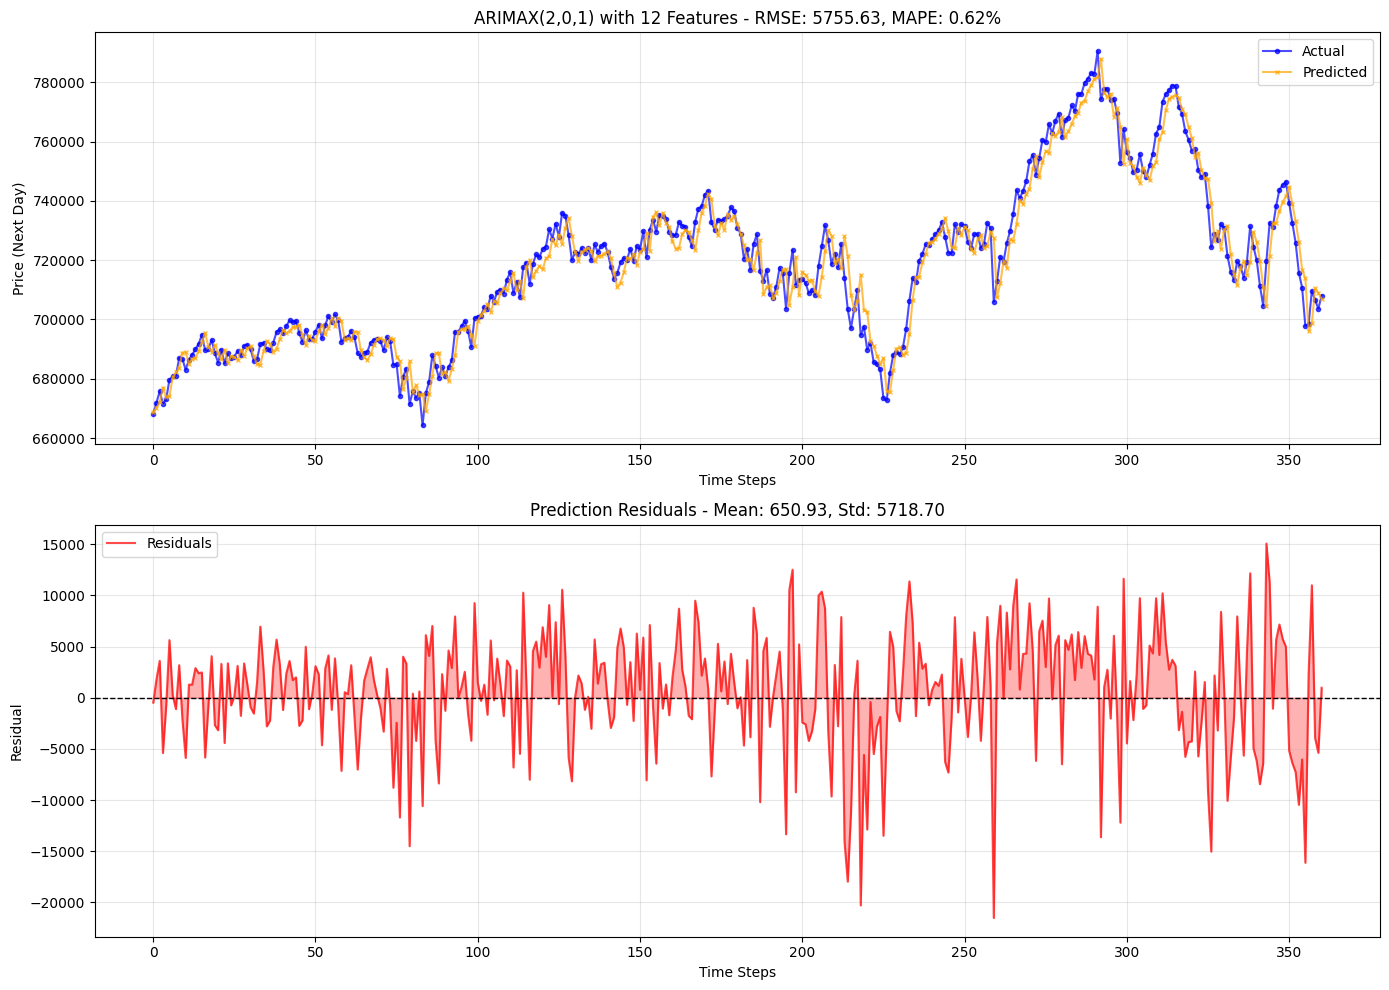

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("ARIMAX(2,0,1) - WITH EXOGENOUS VARIABLES")
print("="*60)

best_order = (2, 0, 1)

features = feature_cols

y_train_arimax = train_scaled['target_scaled']
X_train_arimax = train_scaled[features]

y_val_arimax = val_scaled['target_scaled']
X_val_arimax = val_scaled[features]

y_test_arimax = test_scaled['target_scaled']
X_test_arimax = test_scaled[features]

print(f"\nData shapes:")
print(f"y_train: {y_train_arimax.shape}")
print(f"X_train: {X_train_arimax.shape} (12 features)")
print(f"y_test: {y_test_arimax.shape}")
print(f"X_test: {X_test_arimax.shape}")

print(f"\n📊 Training ARIMAX{best_order} with {len(features)} exogenous features...")

model_arimax = ARIMA(
    endog=y_train_arimax,
    exog=X_train_arimax,
    order=best_order
)
results_arimax = model_arimax.fit()

print("\n" + results_arimax.summary().as_text())

print("\n" + "="*60)
print("Performing one-step ahead forecasting...")
print("="*60)

predictions_test_scaled = []

for i in range(len(y_test_arimax)):
    if i == 0:
        current_model = results_arimax
        pred_scaled = current_model.forecast(steps=1, exog=X_test_arimax.iloc[[i]])
    else:
        updated_endog = pd.concat([y_train_arimax, y_test_arimax.iloc[:i]])
        updated_exog = pd.concat([X_train_arimax, X_test_arimax.iloc[:i]])
        model_updated = ARIMA(
            endog=updated_endog,
            exog=updated_exog,
            order=best_order
        )

        try:
            current_model = model_updated.fit(start_params=results_arimax.params)
        except:
            current_model = model_updated.fit()

        pred_scaled = current_model.forecast(steps=1, exog=X_test_arimax.iloc[[i]])

    predictions_test_scaled.append(pred_scaled.values[0])
    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(y_test_arimax)}")

print(f"\n✅ Forecasting complete: {len(predictions_test_scaled)} predictions")

pred_arimax = scaler_y.inverse_transform(np.array(predictions_test_scaled).reshape(-1, 1))
y_true_arimax = scaler_y.inverse_transform(y_test_arimax.values.reshape(-1, 1))

mae_arimax = mean_absolute_error(y_true_arimax, pred_arimax)
rmse_arimax = np.sqrt(mean_squared_error(y_true_arimax, pred_arimax))
mape_arimax = np.mean(np.abs((y_true_arimax - pred_arimax) / y_true_arimax)) * 100
mse_arimax = mean_squared_error(y_true_arimax, pred_arimax)

print("\n" + "="*60)
print("ARIMAX(2,0,1) PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_arimax:.2f}")
print(f"RMSE : {rmse_arimax:.2f}")
print(f"MAPE : {mape_arimax:.2f}%")
print(f"MSE  : {mse_arimax:.2f}")

print("\n" + "="*60)
print("COMPARISON: ARIMAX vs SARIMAX")
print("="*60)
print(f"ARIMAX(2,0,1)  - MAPE: {mape_arimax:.2f}%")
print(f"SARIMAX(2,0,1) - MAPE: 0.61%")
print(f"Difference: {abs(mape_arimax - 0.61):.2f}%")
print("\nBoth models use the same 12 exogenous features.")
print("The difference is ARIMAX uses statsmodels.tsa.arima.model.ARIMA")
print("while SARIMAX uses statsmodels.tsa.statespace.sarimax.SARIMAX")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_true_arimax, label='Actual', marker='o', markersize=3, alpha=0.7, color='blue')
axes[0].plot(pred_arimax, label='Predicted', marker='x', markersize=3, alpha=0.7, color='orange')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price (Next Day)')
axes[0].set_title(f'ARIMAX(2,0,1) with 12 Features - RMSE: {rmse_arimax:.2f}, MAPE: {mape_arimax:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_true_arimax.flatten() - pred_arimax.flatten()
axes[1].plot(residuals, label='Residuals', color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(len(residuals)), residuals, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Prediction Residuals - Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual_Change': y_true_arima.flatten(),
    'ARIMA_Predicted_Change': pred_arima.flatten()
})

print("Comparison of Actual vs. Predicted Stock Price Change:")
display(comparison_df.head())

Comparison of Actual vs. Predicted Stock Price Change:


,Actual_Change,ARIMA_Predicted_Change
0,668175.0,684302.674385
1,671898.0,668814.617686
2,675733.0,670174.157988
3,671646.0,674125.511177
4,673104.0,672592.736086


In [ ]:
comparison_df = pd.DataFrame({
    'Actual_Change': y_true_arimax.flatten(),
    'ARIMAX_Predicted_Change': pred_arimax.flatten()
})

print("Comparison of Actual vs. Predicted Stock Price Change:")
display(comparison_df.head())

Comparison of Actual vs. Predicted Stock Price Change:


,Actual_Change,ARIMAX_Predicted_Change
0,668175.0,668657.572098
1,671898.0,670115.739081
2,675733.0,672130.107065
3,671646.0,677053.771091
4,673104.0,673906.895364


# **Comparison Model**

In [ ]:
lstm_mae_val = lstm_mae
lstm_mse_val = lstm_mse
lstm_rmse_val = lstm_rmse
lstm_mape_val = lstm_mape

sarimax_mae_val = sarimax_mae
sarimax_mse_val = sarimax_mse
sarimax_rmse_val = sarimax_rmse
sarimax_mape_val = sarimax_mape

nbeats_mae_val = mae_nbeats
nbeats_mse_val = mse_nbeats
nbeats_rmse_val = rmse_nbeats
nbeats_mape_val = mape_nbeats

arima_mae_val = mae_arima
arima_mse_val = mse_arima
arima_rmse_val = rmse_arima
arima_mape_val = mape_arima

arimax_mae_val = mae_arimax
arimax_mse_val = mse_arimax
arimax_rmse_val = rmse_arimax
arimax_mape_val = mape_arimax

metrics_data = {
    'Model': ['LSTM', 'SARIMAX', 'N-BEATS', 'ARIMA', 'ARIMAX'],
    'MSE': [lstm_mse_val, sarimax_mse_val, nbeats_mse_val, arima_mse_val, arimax_mse_val],
    'RMSE': [lstm_rmse_val, sarimax_rmse_val, nbeats_rmse_val, arima_rmse_val, arimax_rmse_val],
    'MAE': [lstm_mae_val, sarimax_mae_val, nbeats_mae_val, arima_mae_val, arimax_mae_val],
    'MAPE': [lstm_mape_val, sarimax_mape_val, nbeats_mape_val, arima_mape_val, arimax_mape_val],
}

df_metrics = pd.DataFrame(metrics_data)

df_metrics_sorted = df_metrics.sort_values(by='MAPE').reset_index(drop=True)
df_metrics_sorted['Rank'] = df_metrics_sorted.index + 1

print('Model Performance Metrics (Sorted by MAPE):')
print(df_metrics_sorted)

output_filename = 'model_comparison_metrics.csv'
df_metrics_sorted.to_csv(output_filename, index=False)

print(f'Model metrics saved to {output_filename}')

Model Performance Metrics (Sorted by MAPE):
     Model           MSE          RMSE           MAE      MAPE  Rank
0  SARIMAX  3.275558e+07   5723.248651   4453.936139  0.006196     1
1    ARIMA  3.051842e+07   5524.348141   4214.009775  0.587761     2
2   ARIMAX  3.312724e+07   5755.626834   4475.333770  0.622302     3
3  N-BEATS  1.907520e+08  13811.300074  10578.943924  1.441567     4
4     LSTM  3.071123e+08  17524.619307  12797.483681  1.732502     5
Model metrics saved to model_comparison_metrics.csv


In [ ]:
import joblib

joblib.dump(results_full, 'best_sarimax_model.joblib')
print("Best SARIMAX model saved as 'best_sarimax_model.joblib'")

Best SARIMAX model saved as 'best_sarimax_model.joblib'
